# CSCE 40103 Module 3, Lecture 3 Code Notebook

## Choosing a Detector for Inbox Protection

This notebook supports the third Module 3 lecture. It compares Naive Bayes, the SVM family, Perceptron, and an optional BERT tokenizer demo.

In [1]:
#%pip install pandas numpy scikit-learn matplotlib seaborn transformers -q

## 1. Import packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## 2. Create the classroom dataset

This is the same small ham/spam dataset used in Lecture 2.

In [3]:
import pandas as pd

# Small classroom dataset created for this module.
# Labels are ham/spam, not true phishing labels.
data = [
    # Ham / legitimate messages
    {"text": "Reminder your project notebook is due Friday on Blackboard", "label": "ham"},
    {"text": "The review session for exam two is tomorrow afternoon", "label": "ham"},
    {"text": "Please submit your lab report through the course website", "label": "ham"},
    {"text": "Office hours are moved to Thursday morning", "label": "ham"},
    {"text": "Your scholarship form is due today through the official portal", "label": "ham"},
    {"text": "Free tutoring is available before the final exam", "label": "ham"},
    {"text": "The department seminar will meet in room 204", "label": "ham"},
    {"text": "Your advisor approved the course registration request", "label": "ham"},
    {"text": "Class is cancelled today because of weather", "label": "ham"},
    {"text": "Please check Blackboard for the updated assignment rubric", "label": "ham"},
    {"text": "The library workshop on research databases starts at noon", "label": "ham"},
    {"text": "Your team meeting has been moved to 3 pm", "label": "ham"},
    {"text": "Campus parking permits are available through the official university portal", "label": "ham"},
    {"text": "Submit your final project proposal by Sunday evening", "label": "ham"},
    {"text": "The professor posted feedback on your notebook submission", "label": "ham"},
    {"text": "Your payroll document is available in the official employee portal", "label": "ham"},
    {"text": "The student success center offers free math help this week", "label": "ham"},
    {"text": "Please review the updated syllabus before class", "label": "ham"},
    {"text": "Your course evaluation survey is now open", "label": "ham"},
    {"text": "Reminder the lab starts at 9 15 tomorrow morning", "label": "ham"},
    {"text": "The official IT help desk will perform maintenance tonight", "label": "ham"},
    {"text": "Your advising appointment is confirmed for Monday", "label": "ham"},
    {"text": "The university portal password reset page is available from the official website", "label": "ham"},
    {"text": "Please bring your laptop to the next class meeting", "label": "ham"},
    {"text": "The research talk slides are posted on the class page", "label": "ham"},
    {"text": "Your financial aid checklist has been updated in the official student portal", "label": "ham"},
    {"text": "The quiz deadline is tonight and the link is on Blackboard", "label": "ham"},
    {"text": "Use the university portal to confirm your emergency contact information", "label": "ham"},
    {"text": "The tutoring center is offering free Python review sessions", "label": "ham"},
    {"text": "Your lab grade has been released in the learning system", "label": "ham"},
    # Spam / suspicious messages
    {"text": "Congratulations you won a free prize click now", "label": "spam"},
    {"text": "Claim your free gift card today", "label": "spam"},
    {"text": "Your account will expire today verify your password now", "label": "spam"},
    {"text": "Urgent action required login to confirm your access", "label": "spam"},
    {"text": "You have been selected for a cash reward claim immediately", "label": "spam"},
    {"text": "Your mailbox storage is full update your account settings now", "label": "spam"},
    {"text": "Verify your payment profile to receive your refund", "label": "spam"},
    {"text": "Click this link to unlock your suspended account", "label": "spam"},
    {"text": "Limited time offer claim your prize before midnight", "label": "spam"},
    {"text": "Your password expires today confirm your login details", "label": "spam"},
    {"text": "Act now to avoid account deletion", "label": "spam"},
    {"text": "You won an exclusive reward open this message now", "label": "spam"},
    {"text": "Your bank account requires immediate verification", "label": "spam"},
    {"text": "Suspicious login detected verify your identity immediately", "label": "spam"},
    {"text": "Your package delivery failed click to reschedule", "label": "spam"},
    {"text": "Free vacation offer claim your ticket now", "label": "spam"},
    {"text": "Update your account access profile today", "label": "spam"},
    {"text": "Important notice your account has been disabled", "label": "spam"},
    {"text": "Click now for a free loan approval", "label": "spam"},
    {"text": "Confirm your password to keep your mailbox active", "label": "spam"},
    {"text": "Your payment failed update card details immediately", "label": "spam"},
    {"text": "You are eligible for a refund confirm your details", "label": "spam"},
    {"text": "Final warning verify account ownership now", "label": "spam"},
    {"text": "Prize winner confirmation required click to claim", "label": "spam"},
    {"text": "Your account access will be suspended unless you review now", "label": "spam"},
    {"text": "Security alert login from unknown device confirm access", "label": "spam"},
    {"text": "Free money transfer offer available today", "label": "spam"},
    {"text": "Immediate response required to restore your account", "label": "spam"},
    {"text": "Confirm your login at the account review page", "label": "spam"},
    {"text": "Urgent account verification needed before midnight", "label": "spam"},
]

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
display(df.head())
print("Class counts:")
print(df["label"].value_counts())

Dataset shape: (60, 2)


,text,label
0,Reminder your project notebook is due Friday o...,ham
1,The review session for exam two is tomorrow af...,ham
2,Please submit your lab report through the cour...,ham
3,Office hours are moved to Thursday morning,ham
4,Your scholarship form is due today through the...,ham


Class counts:
label
ham     30
spam    30
Name: count, dtype: int64


## 3. Train-test split

In [4]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

Training examples: 45
Testing examples: 15


## 4. SVM family in plain English

All SVM classifiers try to separate classes with a useful boundary.

- **Linear SVM:** straight boundary, usually practical for TF-IDF text
- **RBF SVM:** flexible curved boundary, useful for smaller structured data
- **Polynomial SVM:** curved boundary based on feature interactions
- **Sigmoid SVM:** neural-network-like kernel, rarely the first choice

For large sparse TF-IDF text data, Linear SVM is usually the first SVM to try.

## 5. Build a model dictionary

We keep the same TF-IDF settings for every model. Only the classifier changes. This makes the comparison cleaner.

In [5]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale"),
    "Polynomial SVM": SVC(kernel="poly", degree=2, C=1, gamma="scale"),
    "Sigmoid SVM": SVC(kernel="sigmoid", C=1, gamma="scale"),
    "Perceptron": Perceptron(max_iter=1000, random_state=42)
}

list(models.keys())

['Naive Bayes',
 'Linear SVM',
 'RBF SVM',
 'Polynomial SVM',
 'Sigmoid SVM',
 'Perceptron']

## 6. Train and compare models

Each model uses the same TF-IDF vectorizer, same train-test split, and same metrics.

In [6]:
results = []
fitted_detectors = {}

for name, model in models.items():
    detector = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("model", model)
    ])

    detector.fit(X_train, y_train)
    predictions = detector.predict(X_test)
    fitted_detectors[name] = detector

    results.append({
        "model": name,
        "precision_spam": precision_score(y_test, predictions, pos_label="spam", zero_division=0),
        "recall_spam": recall_score(y_test, predictions, pos_label="spam", zero_division=0),
        "f1_spam": f1_score(y_test, predictions, pos_label="spam", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("f1_spam", ascending=False)
display(results_df)

,model,precision_spam,recall_spam,f1_spam
1,Linear SVM,1.000000,1.000000,1.000000
2,RBF SVM,1.000000,1.000000,1.000000
3,Polynomial SVM,1.000000,1.000000,1.000000
4,Sigmoid SVM,1.000000,1.000000,1.000000
0,Naive Bayes,0.777778,1.000000,0.875000
5,Perceptron,0.857143,0.857143,0.857143


## 7. Print detailed classification reports

In [7]:
for name, detector in fitted_detectors.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    predictions = detector.predict(X_test)
    print(classification_report(y_test, predictions, zero_division=0))

Naive Bayes
              precision    recall  f1-score   support

         ham       1.00      0.75      0.86         8
        spam       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15

Linear SVM
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         8
        spam       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

RBF SVM
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         8
        spam       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00

## 8. Visualize results with a simple bar chart

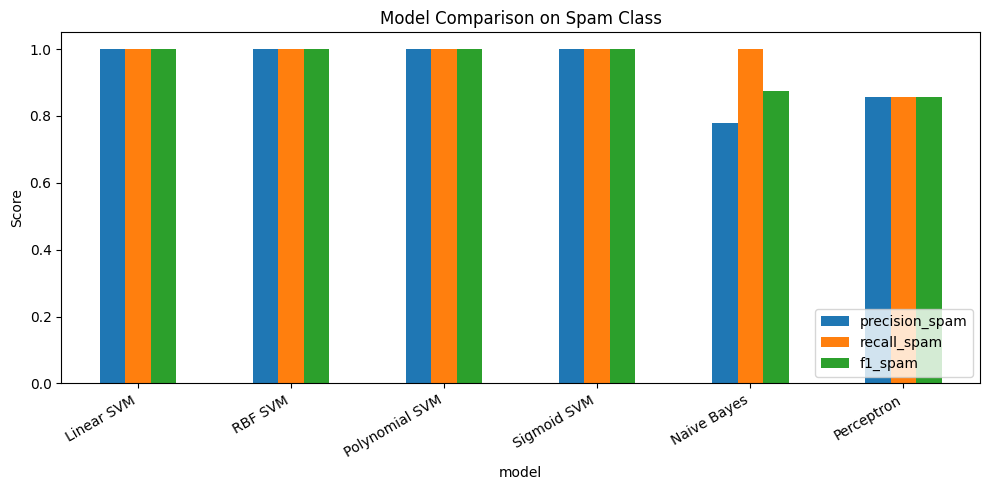

In [8]:
plot_df = results_df.set_index("model")[["precision_spam", "recall_spam", "f1_spam"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison on Spam Class")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Inspect the best model by F1 score

In a real setting, the best model is not always the model with the highest F1 score. You must consider the action: warning, spam folder, quarantine, or human review.

Best model by spam F1: Linear SVM


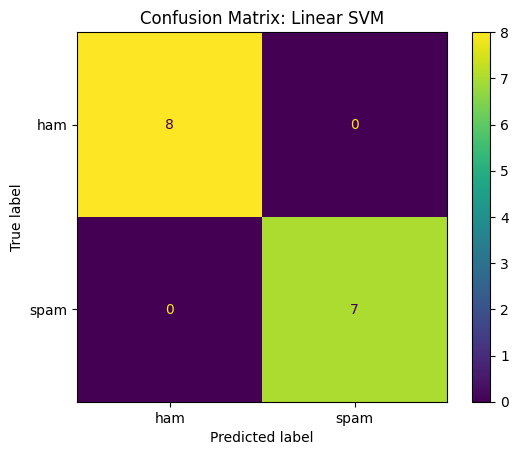

In [9]:
best_model_name = results_df.iloc[0]["model"]
best_detector = fitted_detectors[best_model_name]
best_predictions = best_detector.predict(X_test)

print("Best model by spam F1:", best_model_name)

ConfusionMatrixDisplay.from_predictions(y_test, best_predictions)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## 10. Test models on new messages

These are safe classroom examples. They are not real phishing tests.

In [10]:
new_messages = [
    "Your account access will expire today review your profile now",
    "Free tutoring is available before the exam",
    "Free prize waiting for you click now",
    "Reminder your final project notebook is due Friday on Blackboard",
    "Review your access profile today"
]

comparison_rows = []

for message in new_messages:
    row = {"message": message}
    for name, detector in fitted_detectors.items():
        row[name] = detector.predict([message])[0]
    comparison_rows.append(row)

new_message_results = pd.DataFrame(comparison_rows)
display(new_message_results)

,message,Naive Bayes,Linear SVM,RBF SVM,Polynomial SVM,Sigmoid SVM,Perceptron
0,Your account access will expire today review y...,spam,spam,spam,spam,spam,spam
1,Free tutoring is available before the exam,ham,ham,ham,ham,ham,ham
2,Free prize waiting for you click now,spam,spam,spam,spam,spam,spam
3,Reminder your final project notebook is due Fr...,ham,ham,ham,ham,ham,ham
4,Review your access profile today,spam,spam,spam,spam,spam,ham


## 11. SVM parameter notes

Two important SVM tuning ideas:

- `C`: controls mistake tolerance. Small `C` is more tolerant. Large `C` is stricter.
- `gamma`: controls boundary flexibility for kernel SVMs such as RBF, Polynomial, and Sigmoid. Large `gamma` can overfit.

For TF-IDF text, Linear SVM is often a strong first choice because text has many sparse features.

## 12. Optional toy visualization of SVM boundaries

The next cells use a small numeric toy dataset to visualize how different SVM kernels draw different boundaries. This is not email data. It is only for visual intuition.

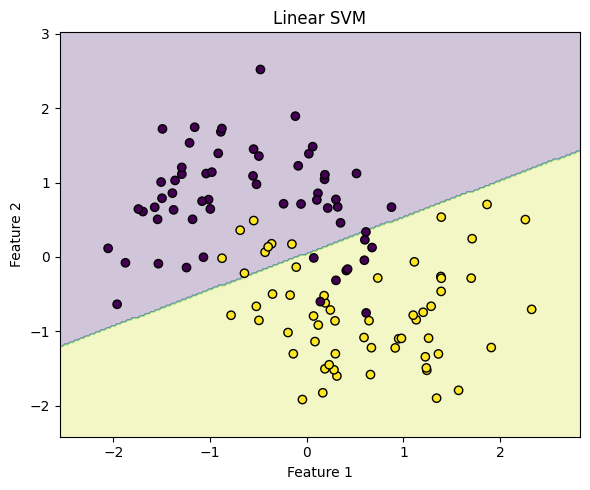

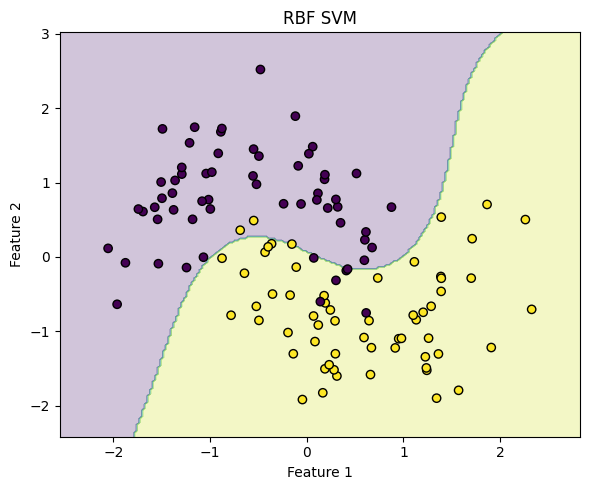

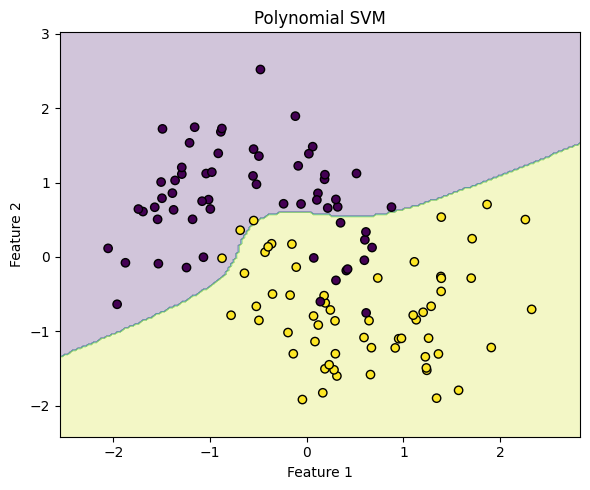

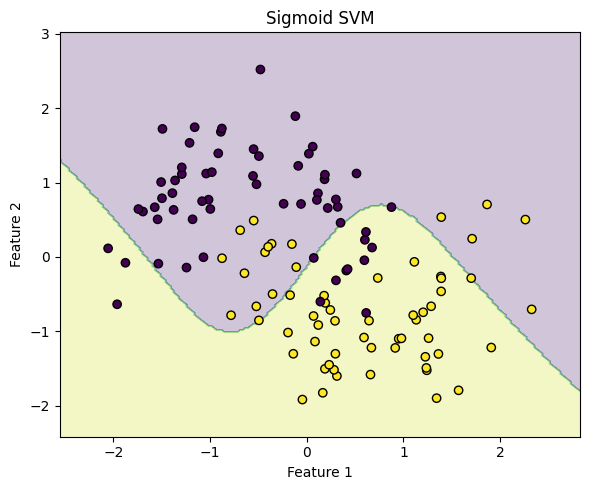

In [11]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X_toy, y_toy = make_moons(n_samples=120, noise=0.25, random_state=42)
scaler = StandardScaler()
X_toy_scaled = scaler.fit_transform(X_toy)

svm_variants = {
    "Linear SVM": SVC(kernel="linear", C=1),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale"),
    "Polynomial SVM": SVC(kernel="poly", degree=3, C=1, gamma="scale"),
    "Sigmoid SVM": SVC(kernel="sigmoid", C=1, gamma="scale")
}

def plot_decision_boundary(model, X, y, title):
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()
    plt.show()

for name, model in svm_variants.items():
    plot_decision_boundary(model, X_toy_scaled, y_toy, name)

## 13. Perceptron bridge

Perceptron learns a simple linear decision rule by correcting mistakes one example at a time. It is useful as a bridge to neural networks, but it is not the strongest detector in this module.

In [12]:
perceptron_detector = fitted_detectors["Perceptron"]
perceptron_predictions = perceptron_detector.predict(X_test)

print(classification_report(y_test, perceptron_predictions, zero_division=0))

              precision    recall  f1-score   support

         ham       0.88      0.88      0.88         8
        spam       0.86      0.86      0.86         7

    accuracy                           0.87        15
   macro avg       0.87      0.87      0.87        15
weighted avg       0.87      0.87      0.87        15



## 14. Optional BERT tokenizer demo

This demo shows how BERT-style models tokenize text into subword units.

This is not a phishing detector. A generic BERT tokenizer only prepares text. A phishing detector would need task-specific labels, fine-tuning, and evaluation.

In [13]:
message = "Your account access will expire today."

try:
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    tokens = tokenizer.tokenize(message)

    print("Message:", message)
    print("BERT tokens:", tokens)

except Exception as error:
    print("BERT tokenizer demo skipped.")
    print("Reason:", error)
    print()
    print("Fallback explanation:")
    print("BERT uses a model-specific tokenizer that may split words into subword pieces.")
    print("Example idea: 'unbelievable' might be split into smaller pieces depending on the tokenizer.")
    print("Install transformers and ensure model download access to run the live demo.")

/Users/bryant/aiForSecurity/module3/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Message: Your account access will expire today.
BERT tokens: ['your', 'account', 'access', 'will', 'ex', '##pire', 'today', '.']


## 15. Prompt engineering examples

Use AI tools to support learning, not to replace your work.

Weak prompt: `Which model is best?`

Stronger prompt:

`I compared Naive Bayes, Linear SVM, RBF SVM, Polynomial SVM, Sigmoid SVM, and Perceptron on a ham/spam dataset. Linear SVM has the best F1, but Naive Bayes has higher precision. In a university email filter, explain the tradeoff and recommend whether the final action should be warning, spam folder, quarantine, or human review.`

## 16. Summary

In this notebook, you compared several detectors using the same text pipeline.

Main lessons:

- Use the same dataset, split, vectorizer, and metrics for fair comparison.
- Linear SVM is often a strong first SVM for TF-IDF text.
- Kernel SVMs add flexibility but also tuning cost.
- Perceptron is useful for learning, not usually the final detector.
- BERT can add context, but it is not automatic and not a detector without task-specific training.
- The final model choice depends on the cost of mistakes and the action taken.